# CHƯƠNG 1: GIỚI THIỆU
## 1.1. Mục tiêu
Sau khi hoàn thành bài thực hành này, sinh viên có thể:
- Hiểu nguyên lý hoạt động của Convolutional Neural Networks
- Xây dựng mô hình CNN bằng PyTorch
- Huấn luyện mô hình cho bài toán phân loại ảnh
- Hiểu vai trò của convolution, pooling và fully connected layers
- Cải thiện mô hình CNN
## 1.2 Giới thiệu bài toán
Trong bài thực hành này chúng ta giải quyết bài toán: Phân loại ảnh

Dataset sử dụng là: CIFAR-10

Dataset gồm:
- 60,000 ảnh màu
- Kích thước ảnh: 
- 10 classes
  
Các classes bao gồm:
- airplane
- automobile
- bird
- cat
- deer
- dog
- frog
- horse
- ship
- truck

# CHƯƠNG 2: KHÁM PHÁ DỮ LIỆU
## 2.1. Chuẩn bị dữ liệu

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [2]:
transform = transforms.Compose(
[
transforms.ToTensor(),
transforms.Normalize((0.5,0.5,0.5),
(0.5,0.5,0.5))
]
)
trainset = torchvision.datasets.CIFAR10(
root='./data',
train=True,
download=True,
transform=transform
)
trainloader = torch.utils.data.DataLoader(
trainset,
batch_size=64,
shuffle=True
)
testset = torchvision.datasets.CIFAR10(
root='./data',
train=False,
download=True,
transform=transform
)
testloader = torch.utils.data.DataLoader(
testset,
batch_size=64,
shuffle=False
)

100%|██████████| 170M/170M [01:11<00:00, 2.39MB/s] 


## 2.2. Khám phá dữ liệu

In [4]:
print(f"Kích thước train dataset: {len(trainset)} ảnh")
print(f"Kích thước test dataset: {len(testset)} ảnh")

Kích thước train dataset: 50000 ảnh
Kích thước test dataset: 10000 ảnh


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.77254903..0.7647059].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7490196..0.4039216].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9764706..0.9137255].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99215686..0.9137255].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9137255..0.7411765].
Clippin

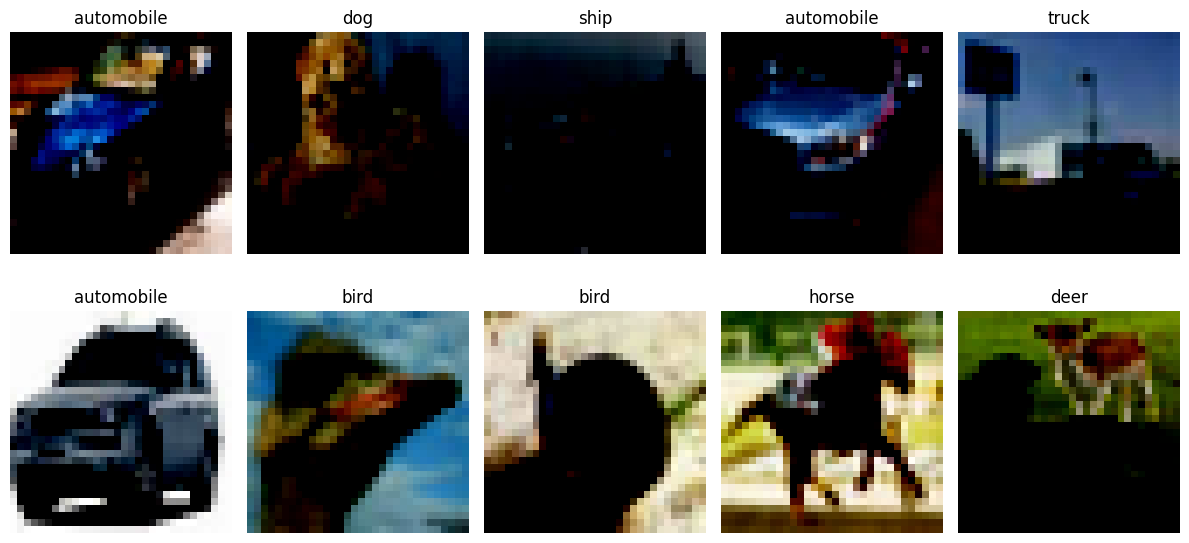

In [5]:
classes = (
'airplane','automobile','bird','cat','deer',
'dog','frog','horse','ship','truck')

dataiter = iter(trainloader)
images, labels = next(dataiter)

fig, axes = plt.subplots(2, 5, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    img = np.transpose(images[i], (1, 2, 0))
    ax.imshow(img)
    ax.set_title(classes[labels[i]])
    ax.axis('off')  
plt.tight_layout()
plt.show()

# CHƯƠNG 3: XÂY DỰNG KIẾN TRÚC CNN
## 3.1. Tìm hiểu kiến trúc CNN
### 3.1.1. Tổng quan
CNN là mạng nơ-ron chuyên dụng để xử lý dữ liệu cấu trúc dữ liệu dạng lưới như hình ảnh và sử dụng cấu trúc phân cấp không gian của các đặc trưng. Cấu trúc bao gồm các tầng với những chức năng khác nhau nối tiếp nhau. 

### 3.1.2. Các lớp trong kiến trúc CNN
#### 3.1.2.1. Lớp đầu vào
Lớp đầu vào biểu diễn dữ liệu đầu vào dưới dạng một tensor có dạng `(height, width, channels)` đối với hình ảnh. Ví dụ một đầu vào có kích thước $256 \times 256$ có dạng `(256, 256, 3)`; ảnh xám kích thước $28 \times 28$ có dạng `(28, 28, 1)` sẽ được tiền xử lý như chuẩn hóa hoặc thay đổi tỷ lệ giá trị.

#### 3.1.2.2. Lớp tích chập
Lớp tích chập là khối quan trọng của CNN, thực hiện phép toán tích chập bằng cách trượt các bộ lọc học được (kernels) qua đầu vào để tạo ra bản đồ đặc trưng (feature maps). Feature maps giúp nắm bắt các mẫu cục bộ và cấu trúc phân cấp không gian bằng cách tận dụng các cơ chế như trường tiếp nhận cục bộ (local receptive fields), chia sẻ tham số để giảm số lượng tham số và tính bất biến dịch chuyển. Quá trình tính toán được thực hiện bằng cách trượt một cửa sổ bộ lọc kích thước $K_h \times K_w$ qua ảnh đầu vào $I(i, j)$:  $$(I*K)(i,j)=\sum_{m=0}^{K_{h}-1}\sum_{n=0}^{K_{w}-1}I(i+m,j+n)K(m,n) \quad $$
Kích thước đầu ra phụ thuộc vào các siêu tham số: Kích thước đầu vào ($I$), Kích thước bộ lọc ($K$), Đệm ($P$), Bước nhảy ($S$), và Tỷ lệ giãn bộ lọc ($D$):  $$O=\lfloor\frac{I-D(K-1)+2P-1}{S}\rfloor+1 \quad $$

Mỗi bộ lọc có một trọng số (weight) cho mỗi pixel của nó trên tất cả các kênh đầu vào, cộng thêm một giá trị chệch (bias) cho mỗi bộ lọc đầu ra:  $$\text{Parameters} = K^{2}\times C_{in}\times C_{out}+C_{out} \quad $$(Trong đó $C_{in}$ là số kênh đầu vào, $C_{out}$ là số kênh đầu ra/số lượng bộ lọc). 

Số lượng thao tác dấu phẩy động (nhân và cộng) được ước tính bằng:  $$\text{FLOPs} \approx O^{2}\times K^{2}\times C_{in}\times C_{out} \quad $$


#### 3.1.2.3. Lớp tích chập
Lớp kích hoạt đưa tính phi tuyến tính vào mạng để học các mẫu phức tạp. Các hàm kích hoạt phổ biến bao gồm:
* **Sigmoid**: $\sigma(x)=\frac{1}{1+e^{-x}}$
* **Tanh**: $\tanh(x)=\frac{e^{x}-e^{-x}}{e^{x}+e^{-x}}$ (đầu ra từ -1 đến 1, lấy số 0 làm trung tâm).
* **ReLU**: $f(x)=\max(0,x)$ (đơn giản, hiệu quả, giải quyết triệt tiêu đạo hàm cho giá trị dương nhưng có thể bị lỗi "dying ReLU").
* **Leaky ReLU**: Cho phép một gradient nhỏ khi $x \le 0$ để sửa lỗi dying ReLU.
* **PReLU (Parametric ReLU)**: Giống Leaky ReLU nhưng hệ số cho vùng âm là một tham số có thể học được.
* **ELU, Swish, GELU**: Các hàm kích hoạt mượt hơn, giúp tăng hiệu suất học tập trong các mô hình sâu hoặc Transformers.

#### 3.1.2.4. Lớp gộp - Pooling
Lớp gộp (Pooling) giúp giảm lấy mẫu bản đồ đặc trưng, giảm độ phức tạp tính toán, giảm quá khớp và tạo tính bất biến dịch chuyển. Các dạng gộp phổ biến:
* Local Pooling: Áp dụng trong các cửa sổ nhỏ không chồng chéo.
* Max Pooling: Lấy giá trị lớn nhất, giúp giữ lại đặc trưng quan trọng. $$\text{Output}(i,j)=\max_{(x,y)\in W}\text{input}(i+x,j+y) \quad $$
* Average Pooling: Lấy giá trị trung bình, cho đầu ra mượt hơn. $$\text{Output}(i,j)=\frac{1}{|W|}\sum_{(x,y)\in W}\text{input}(i+x,j+y) \quad $$
* Global Pooling: Áp dụng trên toàn bộ bản đồ đặc trưng ví dụ như Global Average Pooling - GAP $$\text{Output}(c)=\frac{1}{H\times W}\sum_{i=1}^{H}\sum_{j=1}^{W}\text{Input}(i,j,c) \quad $$ Global Max Pooling - GMP $$\text{Output}(c)=\max_{i,j}\text{input}(i,j,c) \quad$$ Thường dùng ở cuối mạng để thay thế tầng kết nối đầy đủ nhằm giảm mạnh tham số. 

#### 3.1.2.5. Lớp chuẩn hoá Batch
Lớp chuẩn hóa Batch (Batch Normalization) để giải quyết vấn đề **Internal Covariate Shift**, hiện tượng phân phối dữ liệu đầu ra của các lớp ẩn trong mạng nơ-ron liên tục bị thay đổi trong quá trình huấn luyện. Quá trình gồm tính toán trung bình ($\mu_B$) và phương sai ($\sigma_B^2$) của mini-batch.
$$\mu_{B}=\frac{1}{m}\sum_{i=1}^{m}x_{i}, \quad \sigma_{B}^{2}=\frac{1}{m}\sum_{i=1}^{m}(x_{i}-\mu_{B})^{2} \quad$$

Chuẩn hóa ảnh về dạng có trung bình bằng 0 và phương sai bằng 1 với $\epsilon$ là một hằng số rất nhỏ nhằm đảm bảo tính ổn định.
$$\hat{x}_{i}=\frac{x_{i}-\mu_{B}}{\sqrt{\sigma_{B}^{2}+\epsilon}} \quad $$

Sau đó dịch chuyển và tỷ lệ lại bằng hai tham số học được ($\gamma$ và $\beta$).
$$y_{i}=\gamma\hat{x}_{i}+\beta \quad$$

Quá trình chuẩn hoá này làm tăng tính ổn định, cho phép tốc độ học cao hơn, có hiệu ứng điều hòa (regularization) và làm mượt bối cảnh tối ưu hóa.

Ngoài ra trong CNN còn có các lớp biến đổi đặc trưng khác như:
* **Element-wise Addition (Cộng theo từng phần tử)**: Cộng hai tensor cùng kích thước. Đây là cốt lõi của kết nối tắt (skip/residual connections) trong ResNet giúp giải quyết triệt tiêu đạo hàm. $$C(i,j,k)=A(i,j,k)+B(i,j,k) \quad $$
* **Element-wise Multiplication (Nhân theo từng phần tử)**: Dùng trong cơ chế chú ý (attention mechanism) và cổng (gating) để chọn lọc nhấn mạnh hoặc triệt tiêu đặc trưng. $$C(i,j,k)=A(i,j,k)\times B(i,j,k) \quad $$
* **Concatenation (Ghép nối)**: Nối các tensor dọc theo một chiều (thường là chiều kênh - channel), giúp tăng sự đa dạng đặc trưng (như trong các module Inception). Ghép hai tensor $A$ (kích thước $H\times W\times C_A$) và $B$ (kích thước $H\times W\times C_B$) dọc theo chiều sâu (kênh màu) tạo thành tensor $C$ kích thước $H\times W\times(C_A+C_B)$:
  $$C(i,j,k)=\begin{cases}A(i,j,k), & \text{if } 1\le k\le C_{A}\\ B(i,j,k-C_{A}), & \text{if } C_{A}+1\le k\le C_{A}+C_{B}\end{cases} \quad $$

#### 3.1.2.6. Lớp phẳng hoá
Lớp phẳng hóa (Flattening) biến đổi đầu ra nhiều chiều của lớp tích chập thành một vector 1D để làm đầu vào cho lớp kết nối đầy đủ. Phần tử $X(i, j, k)$ của tensor đầu vào sẽ nằm ở vị trí tuyến tính chỉ số $n$ của vector đầu ra $Y$:
  $$Y[n]=X(i,j,k) \quad $$$$\text{với } n=k+C(j+W\cdot i) \quad $$ Với điều kiện bờ: $0\le i<H$, $0\le j<W$, $0\le k<C$.

#### 3.1.2.7. Lớp kết nối
Lớp kết nối đầy đủ (Fully Connected) để kết nối mọi nơ-ron của tầng trước với mọi nơ-ron tầng sau theo phép biến đổi affine: $y = Wx + b$. Sau đó thực hiện lập luận và đưa ra quyết định phân loại hoặc hồi quy, nhưng dễ gây quá khớp do chứa lượng tham số lớn. Nếu lớp có $M$ nơ-ron đầu vào và $N$ nơ-ron đầu ra, số tham số là:
  $$\text{Parameters} = M\times N+N \quad $$

#### 3.1.2.8 Lớp đầu ra
Lớp đầu ra và Hàm mất mát sẽ đưa ra dự đoán cuối cùng của mạng tùy theo bài toán:
* *Phân loại đa lớp*: Dùng tầng FC kết hợp hàm **Softmax** để tạo phân phối xác suất.
* *Phân loại nhị phân*: Dùng một nơ-ron kết hợp hàm **Sigmoid**.
* *Hồi quy*: Dùng tầng FC với kích hoạt tuyến tính để xuất các giá trị liên tục.
* Các hàm mất mát như **Cross-Entropy Loss** và **Mean Squared Error - MSE** được tính toán để đưa ra đánh giá về hiệu quả học của CNN.

## 3.2. Phân tích kiến trúc CNN

In [6]:
class CNN(nn.Module):
    
    def __init__(self):
        
        super(CNN, self).__init__()
        
        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=32,
            kernel_size=3,
            padding=1
        )
        self.conv2 = nn.Conv2d(
            32,
            64,
            3,
            padding=1
        )
        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )
        self.fc1 = nn.Linear(
            64 * 8 * 8,
            512
        )
        self.fc2 = nn.Linear(
            512,
            10
        )
        self.relu = nn.ReLU()
    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 64 * 8 * 8)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model1 = CNN()
print(model1)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
  (relu): ReLU()
)


In [7]:
from torchsummary import summary
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model1 = model1.to(device)
summary(model1, input_size=(3,32,32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
              ReLU-2           [-1, 32, 32, 32]               0
         MaxPool2d-3           [-1, 32, 16, 16]               0
            Conv2d-4           [-1, 64, 16, 16]          18,496
              ReLU-5           [-1, 64, 16, 16]               0
         MaxPool2d-6             [-1, 64, 8, 8]               0
            Linear-7                  [-1, 512]       2,097,664
              ReLU-8                  [-1, 512]               0
            Linear-9                   [-1, 10]           5,130
Total params: 2,122,186
Trainable params: 2,122,186
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 0.85
Params size (MB): 8.10
Estimated Total Size (MB): 8.96
---------------------------------------

Mạng được chia làm hai phần rõ rệt: Khối trích xuất đặc trưng (Feature Extraction) và Khối phân loại (Classification).

**Khối trích xuất đặc trưng thứ nhất:**
* **Conv2d-1 (`conv1`)**: Nhận đầu vào có 3 kênh màu (RGB), sử dụng 32 bộ lọc kích thước 3x3 và đệm `padding=1`. Nhờ có padding, kích thước không gian không đổi. Đầu ra có dạng `[-1, 32, 32, 32]` với **896** tham số.
* **ReLU-2**: Hàm kích hoạt phi tuyến tính ReLU, giữ nguyên kích thước dữ liệu `[-1, 32, 32, 32]`, không tốn tham số.
* **MaxPool2d-3 (`pool`)**: Lớp gộp cực đại với kích thước cửa sổ 2x2 và bước nhảy `stride=2`. Tầng này giảm một nửa chiều cao và chiều rộng của ảnh, đưa đầu ra về kích thước `[-1, 32, 16, 16]`.


**Khối trích xuất đặc trưng thứ hai:**
* **Conv2d-4 (`conv2`)**: Nhận đầu vào 32 kênh từ tầng trước và áp dụng 64 bộ lọc kích thước 3x3, `padding=1`. Đầu ra thu được là `[-1, 64, 16, 16]` với **18,496** tham số.
* **ReLU-5**: Áp dụng hàm phi tuyến tính ReLU, giữ nguyên kích thước `[-1, 64, 16, 16]`.
* **MaxPool2d-6 (`pool`)**: Tiếp tục giảm một nửa kích thước không gian bằng cửa sổ gộp 2x2 (`stride=2`), đưa kết quả về dạng `[-1, 64, 8, 8]`.


**Phép biến đổi phẳng hoá (Flattening):**
* Trong hàm `forward`, câu lệnh `x.view(-1, 64 * 8 * 8)` làm phẳng toàn bộ ma trận đặc trưng thành một vector 1 chiều có kích thước **4,096** phần tử (vì $64 \times 8 \times 8 = 4096$) để làm đầu vào cho tầng kết nối đầy đủ.


**Khối phân loại kết nối đầy đủ (Fully Connected Layers):**
* **Linear-7 (`fc1`)**: Tầng tuyến tính liên kết tất cả 4,096 đặc trưng đầu vào tới 512 nơ-ron ẩn. Đầu ra thu được là `[-1, 512]`. Đây là tầng lớn nhất và chiếm nhiều bộ nhớ nhất với **2,097,664** tham số.
* **ReLU-8**: Hàm kích hoạt phi tuyến tính áp dụng cho đầu ra của tầng ẩn.
* **Linear-9 (`fc2`)**: Tầng tuyến tính cuối cùng ánh xạ từ 512 nơ-ron sang 10 nơ-ron đầu ra (tương ứng với 10 lớp phân loại của tập dữ liệu CIFAR-10). Đầu ra cuối cùng là `[-1, 10]` với **5,130** tham số.

# CHƯƠNG 4: TUỲ CHỈNH KIẾN TRÚC CNN
## 4.1. Thêm lớp tích chập - Convolution layer
Các bộ lọc học được trong lớp tích chập trượt qua hình ảnh đầu vào để tự động phát hiện các mẫu cục bộ cụ thể như cạnh, góc, đường nét hoặc cấu trúc bề mặt. Một lớp tích chập sử dụng nhiều bộ lọc khác nhau, cho phép mô hình học và trích xuất đồng thời nhiều loại đặc trưng phong phú từ cùng một dữ liệu. Phép toán tích chập tạo ra các bản đồ đặc trưng giúp làm nổi bật các thông tin quan trọng được phát hiện để chuyển sang tầng kế tiếp.

Việc xếp chồng nhiều lớp tích chập liên tiếp cho phép mạng học các đặc trưng theo dạng phân cấp từ thấp đến cao.
### 4.1.1 Xây dựng lớp tích chập mới

In [8]:
class CNN_3Layer(nn.Module):
    def __init__(self):
        super(CNN_3Layer, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.fc1 = nn.Linear(128 * 4 * 4, 512)
        self.fc2 = nn.Linear(512, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x))) 
        x = self.pool(self.relu(self.conv2(x))) 
        x = self.pool(self.relu(self.conv3(x)))
        x = x.view(-1, 128 * 4 * 4) 
        
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model2 = CNN_3Layer()
print(model2)

CNN_3Layer(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
  (relu): ReLU()
)


### 4.1.2. So sánh kiến trúc CNN 2 lớp và 3 lớp tích chập

In [4]:
def train_model(model, train_loader, test_loader, epochs=10):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    history = {'train_loss': [], 'test_acc': []}
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            
        epoch_loss = running_loss / len(train_loader.dataset)
        
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                
        epoch_acc = 100 * correct / total
        
        history['train_loss'].append(epoch_loss)
        history['test_acc'].append(epoch_acc)
        print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f} - Test Acc: {epoch_acc:.2f}%")
        
    return history

In [10]:
print("Mạng CNN 2 lớp tích chập")
history_model1 = train_model(model1, trainloader, testloader, epochs=10)
print("Mạng CNN 3 lớp tích chập")
history_model2 = train_model(model2, trainloader, testloader, epochs=10)

Mạng CNN 2 lớp tích chập
Epoch 1/10 - Loss: 1.3043 - Test Acc: 60.63%
Epoch 2/10 - Loss: 0.8987 - Test Acc: 66.30%
Epoch 3/10 - Loss: 0.7163 - Test Acc: 70.88%
Epoch 4/10 - Loss: 0.5609 - Test Acc: 72.30%
Epoch 5/10 - Loss: 0.4122 - Test Acc: 72.55%
Epoch 6/10 - Loss: 0.2773 - Test Acc: 72.84%
Epoch 7/10 - Loss: 0.1737 - Test Acc: 73.05%
Epoch 8/10 - Loss: 0.1112 - Test Acc: 72.29%
Epoch 9/10 - Loss: 0.0827 - Test Acc: 72.19%
Epoch 10/10 - Loss: 0.0714 - Test Acc: 72.82%
Mạng CNN 3 lớp tích chập
Epoch 1/10 - Loss: 1.3752 - Test Acc: 62.41%
Epoch 2/10 - Loss: 0.9341 - Test Acc: 69.09%
Epoch 3/10 - Loss: 0.7374 - Test Acc: 71.04%
Epoch 4/10 - Loss: 0.6041 - Test Acc: 73.48%
Epoch 5/10 - Loss: 0.4935 - Test Acc: 75.66%
Epoch 6/10 - Loss: 0.3819 - Test Acc: 75.06%
Epoch 7/10 - Loss: 0.2876 - Test Acc: 75.28%
Epoch 8/10 - Loss: 0.2103 - Test Acc: 74.67%
Epoch 9/10 - Loss: 0.1543 - Test Acc: 75.38%
Epoch 10/10 - Loss: 0.1145 - Test Acc: 75.62%


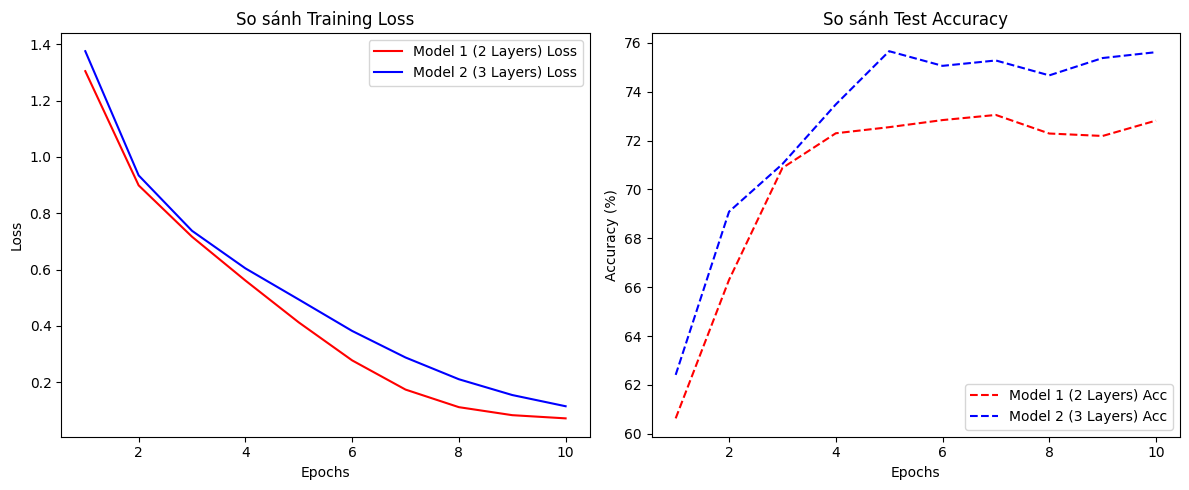

In [11]:
epochs = range(1, 11)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, history_model1['train_loss'], 'r-', label='Model 1 (2 Layers) Loss')
plt.plot(epochs, history_model2['train_loss'], 'b-', label='Model 2 (3 Layers) Loss')
plt.title('So sánh Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history_model1['test_acc'], 'r--', label='Model 1 (2 Layers) Acc')
plt.plot(epochs, history_model2['test_acc'], 'b--', label='Model 2 (3 Layers) Acc')
plt.title('So sánh Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

Mạng CNN 3 lớp tích chập cho kết quả phân loại tốt hơn mạng 2 lớp ngay từ epoch đầu tiên, hiệu quả hơn trong cả quá trình.
Kết quả ở Epoch cuối cùng cho ra kết quả với mạng 3 lớp đạt độ chính xác **75.62%**, cao hơn mạng 2 lớp khoảng **2.80%**. Ngoài ra, biểu đồ cho thấy được mạng 3 lớp vượt ngưỡng 75% từ Epoch 5 (đạt 75.66%) và duy trì ổn định quanh mốc này. Trong khi đó, mạng 2 lớp có dấu hiệu bị bão hòa và khựng lại quanh mức 72% - 73% từ Epoch 4 trở đi.

Cả hai mạng đều thể hiện tốc độ học rất tốt khi chỉ số Training Loss giảm mạnh, liên tục và hội tụ liên tục. Tại Epoch 10, mạng 2 lớp có Training Loss 0.0714 thấp hơn so với mạng 3 lớp 0.1145.

Mặc dù mạng 2 lớp có Training Loss thấp hơn ở các epoch cuối (0.0714 so với 0.1145), nhưng Test Accuracy của nó lại kém hơn. Điều này chứng tỏ mạng 2 lớp đang bị quá khớp (overfitting) nặng hơn mạng 3 lớp. Mô hình học rất tốt trên tập huấn luyện nhưng khả năng dự đoán ảnh mới bị hạn chế.

Việc tăng thêm một tầng tích chập nâng số kênh đặc trưng lên 128 ở lớp `conv3` giúp mô hình trích xuất được các đặc trưng sâu, phức tạp và trừu tượng hơn của ảnh. Điều này giúp tăng cường mạnh mẽ khả năng khái quát hóa của mạng, giúp cải thiện độ chính xác thực tế trên tập dữ liệu.

## 4.2. Thêm Dropout
Để chống hiện tượng quá khớp, Dropout được thêm vào như một kỹ thuật điều hòa hiệu quả nhằm ngăn chặn mạng nơ-ron học tủ hoặc ghi nhớ vẹt dữ liệu huấn luyện.

Trong mỗi lượt huấn luyện, lớp Dropout sẽ tắt ngẫu nhiên một tỷ lệ nơ-ron (với hằng số $p$ nhất định) khiến chúng tạm thời không tham gia vào quá trình tính toán lan truyền tiến và lan truyền ngược. Khi một tập hợp nơ-ron ngẫu nhiên bị tắt đi ở mỗi bước huấn luyện, kiến trúc mạng thực tế thay đổi liên tục. Quá trình này tương tự như việc huấn luyện tập hợp nhiều mô hình mạng nơ-ron nhỏ khác nhau cùng một lúc, kết quả thu được sẽ có độ ổn định và khả năng tổng quát hóa cao hơn rất nhiều khi đối mặt với dữ liệu mới.
### 4.2.1. Xây dựng CNN có Dropout

In [12]:
class CNN_Dropout(nn.Module):

    def __init__(self):
        super(CNN_Dropout, self).__init__()

        self.conv1 = nn.Conv2d(
            in_channels=3, out_channels=32, kernel_size=3, padding=1
        )
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(128 * 4 * 4, 512)
        self.fc2 = nn.Linear(512, 10)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=0.5)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = x.view(-1, 128 * 4 * 4)

        x = self.relu(self.fc1(x))
        x = self.dropout(x)

        x = self.fc2(x)
        return x


model3 = CNN_Dropout()
print(model3)

CNN_Dropout(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
)


### 4.2.2. So sánh Accuracy khi Dropout

In [13]:
history_model3 = train_model(model3, trainloader, testloader, epochs=10)

Epoch 1/10 - Loss: 1.4330 - Test Acc: 61.42%
Epoch 2/10 - Loss: 1.0044 - Test Acc: 69.25%
Epoch 3/10 - Loss: 0.8189 - Test Acc: 69.63%
Epoch 4/10 - Loss: 0.7018 - Test Acc: 74.75%
Epoch 5/10 - Loss: 0.6105 - Test Acc: 76.76%
Epoch 6/10 - Loss: 0.5363 - Test Acc: 75.90%
Epoch 7/10 - Loss: 0.4672 - Test Acc: 77.28%
Epoch 8/10 - Loss: 0.4118 - Test Acc: 77.66%
Epoch 9/10 - Loss: 0.3577 - Test Acc: 78.17%
Epoch 10/10 - Loss: 0.3262 - Test Acc: 76.40%


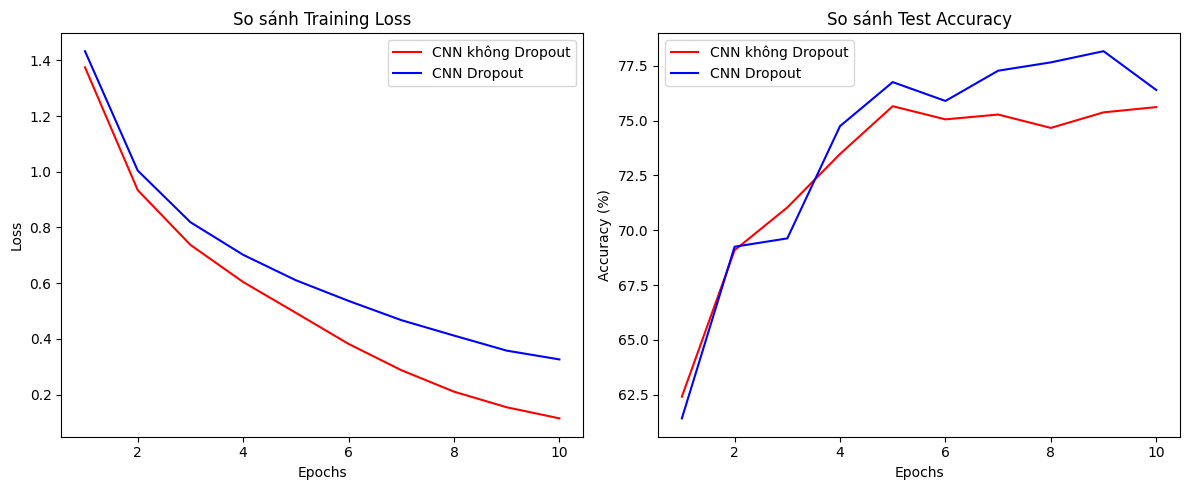

In [14]:
epochs = range(1, 11)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, history_model2['train_loss'], 'r-', label='CNN không Dropout')
plt.plot(epochs, history_model3['train_loss'], 'b-', label='CNN Dropout')
plt.title('So sánh Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history_model2['test_acc'], 'r-', label='CNN không Dropout')
plt.plot(epochs, history_model3['test_acc'], 'b-', label='CNN Dropout')
plt.title('So sánh Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

Mô hình có Dropout cho thấy hiệu suất phân loại vượt trội rõ rệt. Độ chính xác cao nhất trên tập kiểm tra đạt **78.17%** ở Epoch 9, cao hơn đỉnh của mô hình không Dropout khoảng **2.51%** và chỉ đạt 75.66% ở Epoch 5. Kết quả ở Epoch cuối, mô hình có Dropout đạt **76.40%** cao hơn so với mức 75.62% của mô hình thông thường.

Tại Epoch 10, Training Loss của mạng có Dropout dừng ở mức **0.3262**, cao hơn so với mạng không Dropout (**0.1145**). Vì Dropout liên tục ngắt ngẫu nhiên các kết nối nơ-ron trong quá trình học, mạng sẽ khó "học thuộc lòng" toàn bộ tập train hơn, khiến tốc độ giảm Loss trên tập huấn luyện chậm lại.

Việc Training Loss cao hơn nhưng Test Accuracy lại tốt hơn là minh chứng rõ ràng nhất cho thấy Dropout( $p=0.5$ tại tầng `fc1`) đã kiểm soát hiện tượng quá khớp (overfitting) hiệu quả.

Thêm tầng Dropout giúp tăng cường mạnh mẽ khả năng khái quát hóa khi đối mặt với những hình ảnh mới chưa từng thấy trong tập dữ liệu này.

## 4.3. Thay đổi Batch Size 

In [15]:
import time
batch_sizes = [32, 64, 128]
history = {}

for batch_size in batch_sizes:
    print(f"\n--- Đang huấn luyện với Batch Size: {batch_size} ---")

    train_loader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)
    test_loader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False)

    model = CNN_3Layer()  
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    start_time = time.time()

    epochs = 5
    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    end_time = time.time()
    total_train_time = end_time - start_time

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    history[batch_size] = {"time": total_train_time, "accuracy": accuracy}

    print(f"Thời gian chạy: {total_train_time:.2f} giây")
    print(f"Độ chính xác (Accuracy): {accuracy:.2f}%")

print(f"{'Batch Size':<12}{'Thời gian (s)':<18}{'Accuracy (%)':<12}")
for bs, res in history.items():
    print(f"{bs:<12}{res['time']:<18.2f}{res['accuracy']:<12.2f}")


--- Đang huấn luyện với Batch Size: 32 ---
Thời gian chạy: 76.13 giây
Độ chính xác (Accuracy): 74.84%

--- Đang huấn luyện với Batch Size: 64 ---
Thời gian chạy: 65.28 giây
Độ chính xác (Accuracy): 76.43%

--- Đang huấn luyện với Batch Size: 128 ---
Thời gian chạy: 59.76 giây
Độ chính xác (Accuracy): 74.83%
Batch Size  Thời gian (s)     Accuracy (%)
32          76.13             74.84       
64          65.28             76.43       
128         59.76             74.83       


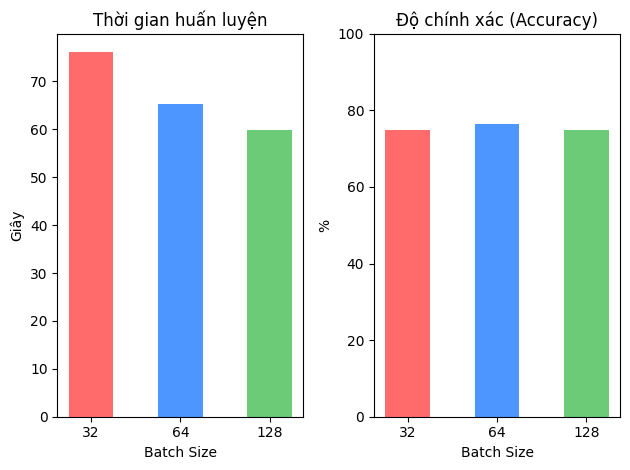

In [16]:
batch_sizes = [str(bs) for bs in history.keys()]
times = [res['time'] for res in history.values()]
accuracies = [res['accuracy'] for res in history.values()]

plt.subplot(1, 2, 1)
colors = ['#FF6B6B', '#4D96FF', '#6BCB77']
plt.bar(batch_sizes, times, color=colors, width=0.5)
plt.title('Thời gian huấn luyện')
plt.xlabel('Batch Size')
plt.ylabel('Giây')

plt.subplot(1, 2, 2)
plt.bar(batch_sizes, accuracies, color=colors, width=0.5)
plt.title('Độ chính xác (Accuracy)')
plt.xlabel('Batch Size')
plt.ylabel('%')
plt.ylim(0, 100)  

plt.tight_layout()

plt.show()

Batch size lớn giúp tận dụng tối đa khả năng tính toán song song của phần cứng (GPU). Đồng thời, số lượng các bước cập nhật trọng số (iterations) trong một epoch giảm xuống, làm giảm hao phí quản lý (overhead) và đẩy nhanh tốc độ xử lý.

Kết quả cho thấy mối quan hệ tỷ lệ nghịch: **Batch size càng lớn, thời gian huấn luyện càng giảm**. Khi tăng từ `32` lên `128`, thời gian chạy giảm từ 76.13 giây xuống còn 59.76 giây (nhanh hơn khoảng **21.5%**).

Đồ thị độ chính xác không biến thiên tuyến tính mà đạt đỉnh ở giữa. Với Batch size = 64 cho kết quả tốt nhất là 76.43%, cao hơn hai cấu hình còn lại khoảng 1.59%.
* Khi Batch size quá nhỏ (`32`), hướng đi của gradient bị nhiễu do dao động ngẫu nhiên cao, khiến mô hình khó hội tụ ổn định trong số lượng epoch ngắn (5 epoch).
* Khi Batch size quá lớn (`128`), dù mô hình học rất nhanh nhưng độ chính xác lại sụt giảm tương đương mức của lô 32 (74.83%).

## 4.4. Thay đổi tốc độ học

In [17]:
learning_rates = [0.01, 0.001, 0.0001]
epochs = 32 
loss_history = {}

for lr in learning_rates:
    print(f"\n--- Đang huấn luyện với Learning Rate: {lr} ---")
    
    model = CNN_3Layer().to(device) 
    criterion = nn.CrossEntropyLoss()
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    epoch_losses = []
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
        average_epoch_loss = running_loss / len(train_loader)
        epoch_losses.append(average_epoch_loss)
        
        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {average_epoch_loss:.4f}")
        
    loss_history[lr] = epoch_losses


--- Đang huấn luyện với Learning Rate: 0.01 ---
Epoch [1/32] - Loss: 2.3678
Epoch [2/32] - Loss: 2.3032
Epoch [3/32] - Loss: 2.3033
Epoch [4/32] - Loss: 2.3033
Epoch [5/32] - Loss: 2.3034
Epoch [6/32] - Loss: 2.3033
Epoch [7/32] - Loss: 2.3034
Epoch [8/32] - Loss: 2.3032
Epoch [9/32] - Loss: 2.3034
Epoch [10/32] - Loss: 2.3033
Epoch [11/32] - Loss: 2.3035
Epoch [12/32] - Loss: 2.3033
Epoch [13/32] - Loss: 2.3033
Epoch [14/32] - Loss: 2.3033
Epoch [15/32] - Loss: 2.3034
Epoch [16/32] - Loss: 2.3033
Epoch [17/32] - Loss: 2.3032
Epoch [18/32] - Loss: 2.3033
Epoch [19/32] - Loss: 2.3034
Epoch [20/32] - Loss: 2.3033
Epoch [21/32] - Loss: 2.3033
Epoch [22/32] - Loss: 2.3033
Epoch [23/32] - Loss: 2.3031
Epoch [24/32] - Loss: 2.3033
Epoch [25/32] - Loss: 2.3033
Epoch [26/32] - Loss: 2.3033
Epoch [27/32] - Loss: 2.3034
Epoch [28/32] - Loss: 2.3034
Epoch [29/32] - Loss: 2.3032
Epoch [30/32] - Loss: 2.3035
Epoch [31/32] - Loss: 2.3034
Epoch [32/32] - Loss: 2.3033

--- Đang huấn luyện với Learnin

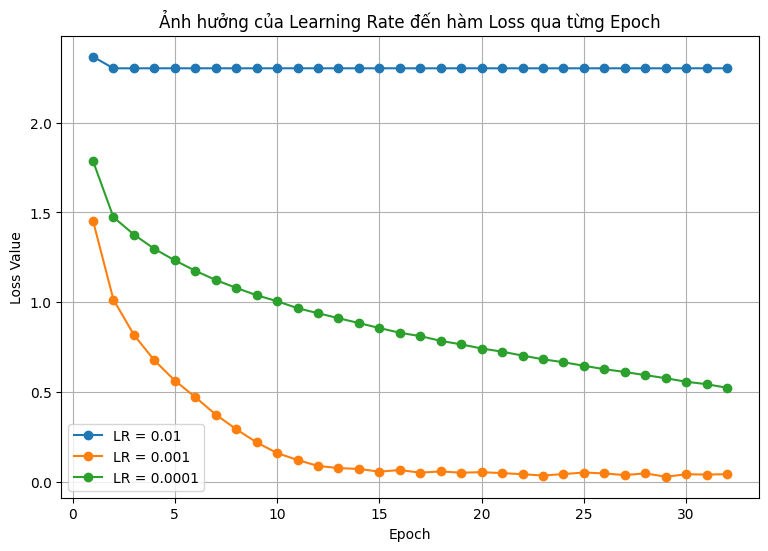

In [18]:
plt.figure(figsize=(9, 6))

for lr, losses in loss_history.items():
    plt.plot(range(1, epochs + 1), losses, marker='o', label=f'LR = {lr}')

plt.title('Ảnh hưởng của Learning Rate đến hàm Loss qua từng Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.legend()      
plt.grid(True)   
plt.show()

Learning Rate = 0.01:
Hàm Loss hoàn toàn "đóng băng" và đi ngang ổn định xung quanh mức **2.3033** từ Epoch 1 cho đến tận Epoch 32.
Đối với tập dữ liệu có 10 lớp, giá trị Cross-Entropy ban đầu khi mô hình đoán mò ngẫu nhiên chính là $-\ln(0.1) \approx 2.3026$. Việc Loss bị kẹt ở mức này chứng tỏ mô hình hoàn toàn không học được gì. Tốc độ học quá lớn khiến thuật toán tối ưu hóa (Adam) thực hiện các bước nhảy quá dài, liên tục vượt quá các vùng cực tiểu cục bộ và làm phân kỳ hoặc mất ổn định các trọng số.


Với Learning Rate = 0.001:
Hàm Loss giảm vô cùng mạnh mẽ và mượt mà. Ngay ở Epoch 1, Loss bắt đầu ở mức 1.4543 và nhanh chóng chạm đáy **0.0277** ở Epoch 29 trước khi kết thúc ở mức **0.0417** tại Epoch 32.
Đây là tốc độ học mặc định và lý tưởng nhất cho thuật toán Adam trong bài toán này. Nó đủ lớn để giúp mô hình thoát khỏi các vùng phẳng (saddle points) nhanh chóng, nhưng cũng đủ nhỏ để tinh chỉnh sâu vào đáy của hàm mất mát, giúp mạng hội tụ đạt hiệu suất cao nhất.

Với Learning Rate = 0.0001:
Hàm Loss giảm rất đều đặn và ổn định (từ 1.7871 ở Epoch 1 xuống **0.5232** ở Epoch 32) nhưng **tốc độ sụt giảm rất chậm**.
Tốc độ học quá nhỏ khiến các bước cập nhật trọng số trở nên cực kỳ "rụt rè". Mặc dù mô hình đang đi đúng hướng và không bị nhiễu, nhưng sau 32 epoch nó vẫn chưa thể hội tụ về mức tối ưu. Để đạt được mức Loss thấp như cấu hình `LR = 0.001`, cấu hình này sẽ cần số lượng epoch lớn hơn gấp nhiều lần có thể lên tới 100 - 150 epoch, gây lãng phí lớn về thời gian và tài nguyên phần cứng.

## 4.5. Tăng cường dữ liệu - Data Augmentation
Data Augmentation là quá trình tạo ra các mẫu dữ liệu huấn luyện mới từ các mẫu dữ liệu sẵn có bằng cách áp dụng các phép biến đổi kỹ thuật số (như xoay, lật, phóng to, thu nhỏ, thay đổi độ sáng, thêm nhiễu...).

In [20]:
transform_train = transforms.Compose([  
    transforms.RandomHorizontalFlip(),         
    transforms.RandomRotation(15),             
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

In [21]:
history_model4 = train_model(model, trainloader, testloader, epochs=10)

Epoch 1/10 - Loss: 1.0617 - Test Acc: 68.33%
Epoch 2/10 - Loss: 0.8758 - Test Acc: 71.00%
Epoch 3/10 - Loss: 0.7940 - Test Acc: 74.17%
Epoch 4/10 - Loss: 0.7308 - Test Acc: 73.22%
Epoch 5/10 - Loss: 0.6750 - Test Acc: 76.35%
Epoch 6/10 - Loss: 0.6306 - Test Acc: 77.31%
Epoch 7/10 - Loss: 0.5921 - Test Acc: 77.21%
Epoch 8/10 - Loss: 0.5535 - Test Acc: 77.95%
Epoch 9/10 - Loss: 0.5208 - Test Acc: 78.66%
Epoch 10/10 - Loss: 0.4902 - Test Acc: 78.53%


Kỹ thuật tăng cường dữ liệu giúp mô hình đạt độ chính xác cao nhất. Độ chính xác trên tập kiểm tra đạt đỉnh **78.66%** ở Epoch 9. 
Kết thúc ở Epoch 10, mô hình duy trì độ chính xác ấn tượng ở mức **78.53%**.

Tại Epoch 10, Training Loss của mô hình dừng ở mức **0.4902**. Con số này cao hơn rõ rệt so với mạng 3 lớp không biến đổi dữ liệu (0.1145) và mạng có Dropout (0.3262). Vì dữ liệu ảnh liên tục bị thay đổi ngẫu nhiên qua mỗi epoch, mô hình không bao giờ gặp lại một bức ảnh hoàn toàn trùng khớp. Điều này làm tăng độ khó của bài toán huấn luyện một cách có chủ đích, khiến Training Loss giảm chậm hơn nhưng đổi lại mạng nơ-ron bắt buộc phải học các đường nét đặc trưng cốt lõi thay vì học thuộc lòng từng pixel cố định.

Data Augmentation đã giải quyết triệt để bài toán quá khớp bằng cách "phóng đại" tập dữ liệu huấn luyện một cách nhân tạo. Khoảng cách hiệu năng giữa tập huấn luyện và tập kiểm tra được thu hẹp tối đa, chứng minh khả năng khái quát hóa cực kỳ mạnh mẽ của mô hình trên dữ liệu thực tế CIFAR-10.
Khác với các mô hình trước thường bị bão hòa hoặc trồi sụt độ chính xác từ rất sớm (sau Epoch 4 hoặc 5), mô hình có Data Augmentation tăng trưởng độ chính xác rất đều đặn và bền vững qua từng epoch (từ 68.33% ở Epoch 1 lên thẳng vùng 78% ở các epoch cuối).

# CHƯƠNG 5: KẾT QUẢ THỰC NGHIỆM
## 5.1. Ma trận nhầm lẫn

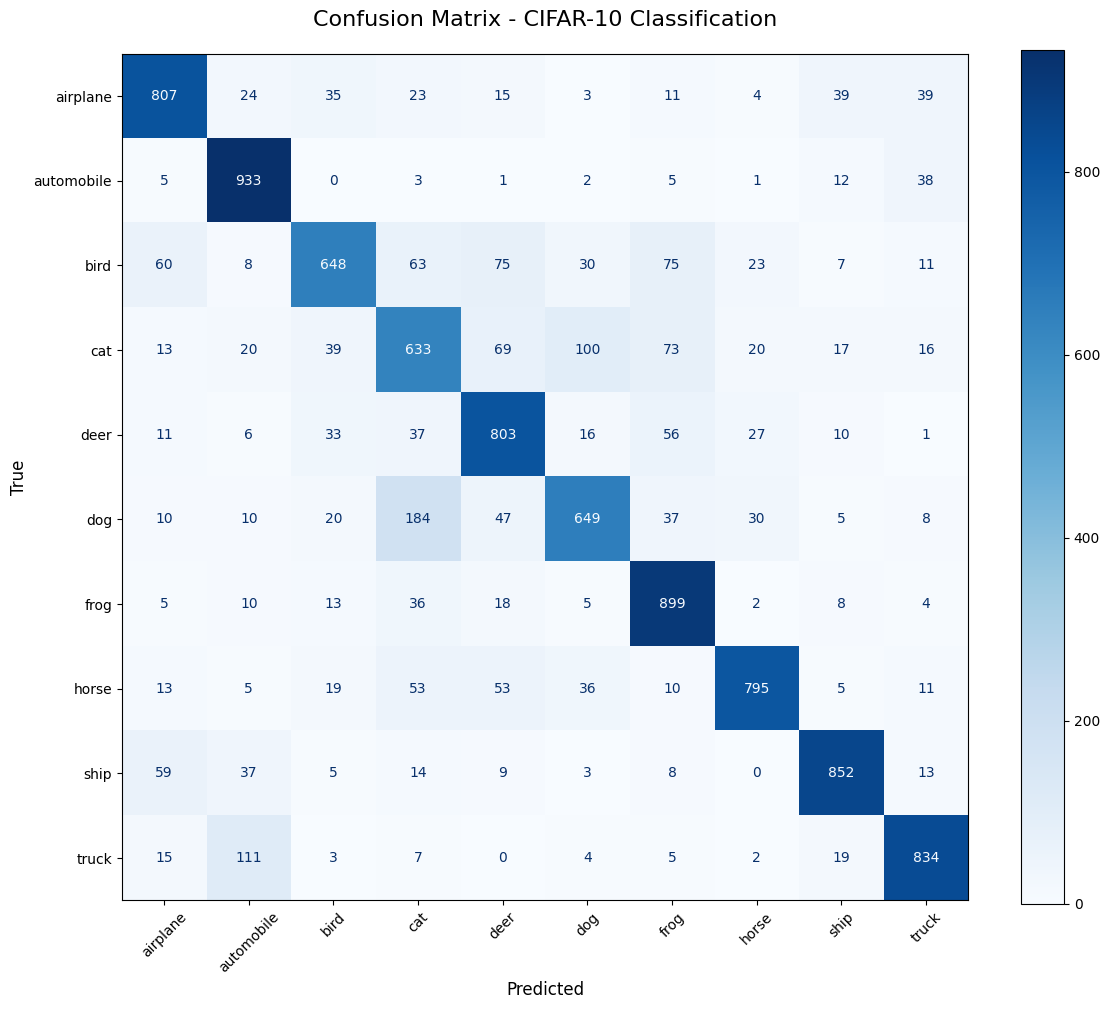

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import torch

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap='Blues', ax=ax, values_format='d', xticks_rotation=45)

plt.title('Confusion Matrix - CIFAR-10 Classification', fontsize=16, pad=20)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.tight_layout()
plt.show()

## 5.2 Các tham số tối ưu

Dựa trên các kết quả thực nghiệm thay đổi kiến trúc mạng và siêu tham số, bộ cấu hình tối ưu nhất giúp mô hình CNN đạt hiệu suất phân loại cao nhất trên tập dữ liệu CIFAR-10 được tổng hợp dưới đây:

| Tham số / Cấu hình | Giá trị tối ưu | Chứng minh từ kết quả thực nghiệm |
| --- | --- | --- |
| **Kiến trúc mạng (Số lớp tích chập)** | **3 lớp tích chập** (`CNN_3Layer`) | Giúp mô hình trích xuất được các đặc trưng sâu và trừu tượng hơn. Kết quả đạt độ chính xác **75.62%**, cao hơn mạng 2 lớp khoảng 2.80% và duy trì độ ổn định tốt hơn. |
| **Dropout** | **Có sử dụng (p = 0.5)** tại tầng `fc1` | Kiểm soát hiệu quả hiện tượng quá khớp (overfitting). Giúp tăng Test Accuracy đạt đỉnh **78.17%** ở Epoch 9 (cao hơn mô hình không có Dropout khoảng 2.51%). |
| **Kích thước lô (Batch Size)** | **64** | Đạt hiệu suất chính xác tốt nhất (**76.43%** sau 5 epoch). Cấu hình này giúp cân bằng tối ưu giữa thời gian huấn luyện (65.28 giây) và hướng đi ổn định của gradient so với Batch size 32 hoặc 128. |
| **Tốc độ học (Learning Rate)** | **0.001** | Là tốc độ học lý tưởng nhất cho thuật toán Adam trong bài toán này. Hàm Loss giảm mạnh mẽ, mượt mà và hội tụ sâu về mức **0.0417** ở Epoch 32, tránh được lỗi đóng băng (ở LR = 0.01) hoặc hội tụ quá chậm (ở LR = 0.0001). |
| **Tăng cường dữ liệu (Data Augmentation)** | **Có áp dụng** (`RandomHorizontalFlip`, `RandomRotation(15)`) | Giúp mô hình đạt độ chính xác cao nhất trong toàn bộ bài thực hành (đạt đỉnh **78.66%** tại Epoch 9). Giải quyết triệt để bài toán quá khớp bằng cách nâng cao khả năng khái quát hóa dữ liệu. |

# CHƯƠNG 6: CẢI THIỆN MÔ HÌNH

In [5]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

BATCH_SIZE = 64

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

class CNN_Opt(nn.Module):
    def __init__(self):
        super(CNN_Opt, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) 
 
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
  
        self.flatten = nn.Flatten()
        
        self.fc1 = nn.Linear(128 * 4 * 4, 512)
        self.relu_fc1 = nn.ReLU()
        
        self.dropout = nn.Dropout(p=0.5)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))
        x = self.flatten(x)

        x = self.dropout(self.relu_fc1(self.fc1(x)))

        x = self.fc2(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_opt = CNN_Opt().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model_opt.parameters(), lr=0.001)

print(model_opt)

CNN_Opt(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=2048, out_features=512, bias=True)
  (relu_fc1): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
)


In [6]:
history_model_opt = train_model(model_opt, trainloader, testloader, epochs=32)

Epoch 1/32 - Loss: 1.5183 - Test Acc: 56.17%
Epoch 2/32 - Loss: 1.1491 - Test Acc: 66.10%
Epoch 3/32 - Loss: 0.9897 - Test Acc: 69.93%
Epoch 4/32 - Loss: 0.8948 - Test Acc: 72.67%
Epoch 5/32 - Loss: 0.8365 - Test Acc: 73.43%
Epoch 6/32 - Loss: 0.7937 - Test Acc: 74.91%
Epoch 7/32 - Loss: 0.7510 - Test Acc: 75.21%
Epoch 8/32 - Loss: 0.7222 - Test Acc: 76.11%
Epoch 9/32 - Loss: 0.6973 - Test Acc: 76.61%
Epoch 10/32 - Loss: 0.6784 - Test Acc: 77.23%
Epoch 11/32 - Loss: 0.6583 - Test Acc: 77.42%
Epoch 12/32 - Loss: 0.6443 - Test Acc: 77.92%
Epoch 13/32 - Loss: 0.6244 - Test Acc: 78.81%
Epoch 14/32 - Loss: 0.6149 - Test Acc: 78.98%
Epoch 15/32 - Loss: 0.5977 - Test Acc: 78.91%
Epoch 16/32 - Loss: 0.5884 - Test Acc: 79.54%
Epoch 17/32 - Loss: 0.5726 - Test Acc: 79.47%
Epoch 18/32 - Loss: 0.5658 - Test Acc: 79.77%
Epoch 19/32 - Loss: 0.5558 - Test Acc: 79.77%
Epoch 20/32 - Loss: 0.5470 - Test Acc: 79.92%
Epoch 21/32 - Loss: 0.5399 - Test Acc: 80.73%
Epoch 22/32 - Loss: 0.5330 - Test Acc: 80.1

# CHƯƠNG 7: KẾT LUẬN

Tóm lại, những giới hạn này là sự đánh đổi có chủ đích giữa chi phí tính toán, ràng buộc hệ thống và độ chính xác phân loại. BasicCNN vẫn là một giải pháp tối ưu, giải quyết thành công bài toán cân bằng giữa kích thước mô hình siêu nhẹ và hiệu năng nhận dạng tín hiệu viễn thông/radar với độ tin cậy cao.


Chương 7 đã đi sâu vào việc phân tích và đánh giá toàn diện hiệu năng của kiến trúc mạng BasicCNN. Các kết quả thực nghiệm và ma trận nhầm lẫn đã minh chứng rõ ràng sự hiệu quả của mô hình trong việc phân loại các dải tín hiệu vô tuyến, đặc biệt là sự xuất sắc tuyệt đối đối với các nhóm tín hiệu radar và điều tần. Mặc dù vẫn còn tồn tại những thách thức khách quan trong việc phân tách các dạng điều chế pha (QAM, PSK) do giới hạn của ảnh phổ cường độ, nhưng xét trên tổng thể, hệ thống đã giải quyết thành công bài toán tối ưu hóa đa mục tiêu: vừa duy trì kích thước mạng siêu nhẹ (96.812 tham số), vừa đảm bảo khả năng tổng quát hóa cao với độ chính xác 92,45%. Những phân tích này chính là cơ sở vững chắc để đi đến các kết luận cuối cùng của đồ án."

